# <center>Case Study 7: GQR Constrained Sensor Classes</center>

Exercise RAVEN GQR constraints on the same 2D parameterized field family and compare each constrained selection against the equivalent pySensors call.

In [1]:

import os
import sys
import html
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import patches
from IPython.display import HTML, display
import numpy as np
import pandas as pd
import pysensors as ps


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "ravenframework").is_dir() and (path / "tests").is_dir():
            return path
    raise RuntimeError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root()
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22})
seed = 42
NX = 18
NY = 12
x_axis = np.linspace(0.0, 1.0, NX)
y_axis = np.linspace(0.0, 1.0, NY)
XX, YY = np.meshgrid(x_axis, y_axis, indexing="xy")
X = XX.ravel()
Y = YY.ravel()
point_id = np.arange(X.size)
alphas = np.linspace(0.1, 1.0, 6)
time_slice = 0.45


def parameter_field(alpha, t=time_slice):
    left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
    right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
    wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
    return np.exp(-0.85 * t) * ((2.0 + 0.25 * alpha) * left + (0.6 + 1.35 * alpha) * right) + 0.28 * np.cos(2.0 * np.pi * t) * wave


def sensor_costs():
    expensive_center = 1.0 + 4.0 * np.exp(-(((X - 0.52) / 0.22) ** 2 + ((Y - 0.50) / 0.20) ** 2))
    edge_bonus = 0.5 * (np.abs(X - 0.5) + np.abs(Y - 0.5))
    return expensive_center + edge_bonus


def field_image(values):
    return np.asarray(values, dtype=float).reshape(NY, NX)


def spatial_frame(ax, values, title, limits=None, cmap="coolwarm", sensors=None):
    if limits is None:
        limits = (float(np.nanmin(values)), float(np.nanmax(values)))
    image = ax.imshow(
        field_image(values),
        extent=[x_axis.min(), x_axis.max(), y_axis.min(), y_axis.max()],
        origin="lower",
        cmap=cmap,
        vmin=limits[0],
        vmax=limits[1],
        interpolation="bicubic",
        aspect="equal",
    )
    if sensors is not None:
        sensors = np.asarray(sensors, dtype=int)
        ax.scatter(X[sensors], Y[sensors], facecolors="none", edgecolors="black", s=82, linewidths=1.2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    return image


def nearest_point_indices(frame, x_col="x", y_col="y"):
    grid = np.column_stack([X, Y])
    indices = []
    distances = []
    for _, row in frame.iterrows():
        point = np.array([row[x_col], row[y_col]])
        distance = np.linalg.norm(grid - point, axis=1)
        index = int(np.argmin(distance))
        indices.append(index)
        distances.append(float(distance[index]))
    return np.asarray(indices, dtype=int), np.asarray(distances)


def style_sensor_comparison(table, caption, columns=None):
    if columns is None:
        columns = [
            "case", "match", "order_match", "sensor_id", "pySensors order", "RAVEN order",
            "pySensors value", "RAVEN value", "pySensors coefficient",
            "pySensors x", "RAVEN x", "pySensors y", "RAVEN y", "nearest_grid_distance",
        ]
    visible_columns = [column for column in columns if column in table.columns]

    def highlight(row):
        sensor_match = bool(row.get("match", False))
        order_match = bool(row.get("order_match", True))
        if sensor_match and order_match:
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        if sensor_match:
            return ["background-color: #fff2cc; color: #4a3600" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "order_match": lambda value: "yes" if bool(value) else "no",
        "pySensors order": "{:.0f}",
        "RAVEN order": "{:.0f}",
        "pySensors value": "{:.6f}",
        "RAVEN value": "{:.6f}",
        "pySensors coefficient": "{:.6f}",
        "pySensors x": "{:.6f}",
        "RAVEN x": "{:.6f}",
        "pySensors y": "{:.6f}",
        "RAVEN y": "{:.6f}",
        "nearest_grid_distance": "{:.2e}",
    }
    return (
        table[visible_columns]
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in visible_columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )


def style_match_table(table, caption):
    def highlight(row):
        if bool(row.get("match", False)):
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "pySensors rmse": "{:.6e}",
        "RAVEN rec_rmse": "{:.6e}",
        "relative_l2": "{:.6e}",
        "rmse": "{:.6e}",
    }
    return (
        table
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in table.columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )

def compare_sensor_tables(case_name, pysensors_indices, raven_frame, reference_matrix):
    raven_indices, raven_distances = nearest_point_indices(raven_frame)
    pysensors_compare = pd.DataFrame({
        "case": case_name,
        "sensor_id": np.asarray(pysensors_indices, dtype=int),
        "pySensors order": np.arange(1, len(pysensors_indices) + 1),
        "pySensors value": reference_matrix[0, pysensors_indices],
        "pySensors x": X[pysensors_indices],
        "pySensors y": Y[pysensors_indices],
    })
    raven_compare = pd.DataFrame({
        "case": case_name,
        "sensor_id": raven_indices,
        "RAVEN order": raven_frame["sensor"].to_numpy(),
        "RAVEN value": raven_frame["T"].to_numpy(),
        "RAVEN x": raven_frame["x"].to_numpy(),
        "RAVEN y": raven_frame["y"].to_numpy(),
        "nearest_grid_distance": raven_distances,
    })
    comparison = pysensors_compare.merge(raven_compare, on=["case", "sensor_id"], how="outer")
    comparison = comparison.sort_values(["case", "pySensors order", "RAVEN order"], na_position="last").reset_index(drop=True)
    comparison["same sensor"] = comparison["pySensors order"].notna() & comparison["RAVEN order"].notna()
    comparison["same location"] = np.isclose(comparison["pySensors x"], comparison["RAVEN x"]) & np.isclose(comparison["pySensors y"], comparison["RAVEN y"])
    comparison["same value"] = np.isclose(comparison["pySensors value"], comparison["RAVEN value"])
    comparison["match"] = comparison[["same sensor", "same location", "same value"]].all(axis=1)
    comparison["order_match"] = comparison["pySensors order"].eq(comparison["RAVEN order"])
    return comparison, raven_indices


def run_raven(raven_case_dir, raven_input):
    raven_case_dir.mkdir(parents=True, exist_ok=True)
    raven_output = raven_case_dir / "outPP.csv"
    if raven_output.exists():
        raven_output.unlink()

    import subprocess
    run_env = os.environ.copy()
    run_env["PATH"] = f"{repo_root}{os.pathsep}{run_env.get('PATH', '')}"
    run_env["INSTALLATION_MANAGER"] = "CONDA"
    run_env["RAVEN_LIBS_NAME"] = "raven_spsl_043"
    run_env["PYTHON_COMMAND"] = sys.executable
    run_env.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "mpl_raven"))

    print(f"$ raven_framework {raven_input.name}")
    run_result = subprocess.run(
        ["raven_framework", raven_input.name],
        cwd=str(raven_case_dir),
        env=run_env,
        text=True,
        capture_output=True,
    )
    print(run_result.stdout)
    if run_result.stderr:
        print(run_result.stderr)
    if run_result.returncode != 0:
        raise RuntimeError(f"RAVEN failed with exit code {run_result.returncode}")
    if not raven_output.exists():
        raise RuntimeError(f"RAVEN completed but did not write {raven_output}")
    print(f"Fresh RAVEN run completed: {raven_output}")
    return pd.read_csv(raven_output)


def write_steady_external_model(raven_case_dir):
    (raven_case_dir / "genSparseSensingSteady2D.py").write_text(
        textwrap.dedent(
            """\
            import numpy as np

            NX = 18
            NY = 12
            TIME_SLICE = 0.45
            X_AXIS = np.linspace(0.0, 1.0, NX)
            Y_AXIS = np.linspace(0.0, 1.0, NY)
            XX, YY = np.meshgrid(X_AXIS, Y_AXIS, indexing='xy')
            X = XX.ravel()
            Y = YY.ravel()

            def read_alpha(Input, default=0.5):
              if isinstance(Input, dict):
                raw = Input.get('alpha', default)
              else:
                raw = getattr(Input, 'alpha', default)
              return float(np.asarray(raw).reshape(-1)[0])

            def parameter_field(alpha, t=TIME_SLICE):
              left = np.exp(-(((X - (0.25 + 0.10 * alpha)) / 0.16) ** 2 + ((Y - 0.35) / 0.18) ** 2))
              right = np.exp(-(((X - 0.72) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha)) / 0.16) ** 2))
              wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
              return np.exp(-0.85 * t) * ((2.0 + 0.25 * alpha) * left + (0.6 + 1.35 * alpha) * right) + 0.28 * np.cos(2.0 * np.pi * t) * wave

            def sensor_costs():
              expensive_center = 1.0 + 4.0 * np.exp(-(((X - 0.52) / 0.22) ** 2 + ((Y - 0.50) / 0.20) ** 2))
              edge_bonus = 0.5 * (np.abs(X - 0.5) + np.abs(Y - 0.5))
              return expensive_center + edge_bonus

            def run(self, Input):
              alpha = read_alpha(Input)
              self.pointID = np.arange(X.size)
              self.x = X.copy()
              self.y = Y.copy()
              self.T = parameter_field(alpha)
              self.cost = sensor_costs()
              self._indexMap = {'x': ['pointID'], 'y': ['pointID'], 'T': ['pointID'], 'cost': ['pointID']}
            """
        )
    )


def write_steady_xml(raven_case_dir, case_name, goal_body, output_mode):
    raven_alpha_values = " ".join(f"{value:.17g}" for value in alphas)
    if output_mode == "sensor":
        out_data_object = '<DataSet name="outPP"><Output>x, y, T</Output><Index var="sensor">x, y, T</Index></DataSet>'
    elif output_mode == "candidate_tpgr":
        out_data_object = '<DataSet name="outPP"><Input>InputPlaceHolder</Input><Output>candidate_x, candidate_y, candidate_T, std, onePtEnergyLandscape, twoPtEnergyLandscape</Output><Index var="candidateSensor">candidate_x, candidate_y, candidate_T, std, onePtEnergyLandscape, twoPtEnergyLandscape</Index></DataSet>'
    else:
        raise ValueError(output_mode)
    raven_input = raven_case_dir / f"{case_name}.xml"
    raven_input.write_text(
        textwrap.dedent(
            f"""\
            <?xml version="1.0" ?>
            <Simulation verbosity="quiet">
              <RunInfo><WorkingDir>.</WorkingDir><Sequence>sample, pp, print</Sequence><batchSize>1</batchSize></RunInfo>
              <Models><ExternalModel name="genT" subType="" ModuleToLoad="genSparseSensingSteady2D"><inputs>alpha</inputs><outputs>pointID, x, y, T, cost</outputs></ExternalModel><PostProcessor name="mySPSL" subType="SparseSensing"><Goal subType="reconstruction">{goal_body}</Goal></PostProcessor></Models>
              <Distributions><Uniform name="uniAlpha"><lowerBound>0.0</lowerBound><upperBound>1.0</upperBound></Uniform></Distributions>
              <Samplers><Grid name="alphaGrid"><variable name="alpha"><distribution>uniAlpha</distribution><grid construction="custom" type="value">{raven_alpha_values}</grid></variable></Grid></Samplers>
              <Steps><MultiRun name="sample"><Input class="DataObjects" type="PointSet">placeholder</Input><Model class="Models" type="ExternalModel">genT</Model><Sampler class="Samplers" type="Grid">alphaGrid</Sampler><Output class="DataObjects" type="DataSet">dataDS</Output></MultiRun><PostProcess name="pp"><Input class="DataObjects" type="DataSet">dataDS</Input><Model class="Models" type="PostProcessor">mySPSL</Model><Output class="DataObjects" type="DataSet">outPP</Output></PostProcess><IOStep name="print"><Input class="DataObjects" type="DataSet">outPP</Input><Output class="OutStreams" type="Print">outPP</Output></IOStep></Steps>
              <DataObjects><PointSet name="placeholder"><Input>alpha</Input><Output>OutputPlaceHolder</Output></PointSet><DataSet name="dataDS"><Input>alpha</Input><Output>x, y, T, cost</Output><Index var="pointID">x, y, T, cost</Index></DataSet>{out_data_object}</DataObjects>
              <OutStreams><Print name="outPP"><type>csv</type><source>outPP</source><what>output</what></Print></OutStreams>
            </Simulation>
            """
        ).lstrip()
    )
    return raven_input


T = np.stack([parameter_field(alpha) for alpha in alphas])
cost = sensor_costs()
info_df = pd.DataFrame({"x": X, "y": Y, "T": T[0], "cost": cost})
print(f"matrix shape: {T.shape}")
print(f"candidate sensors: {X.size}")


matrix shape: (6, 216)
candidate sensors: 216


## Constraint problem setup

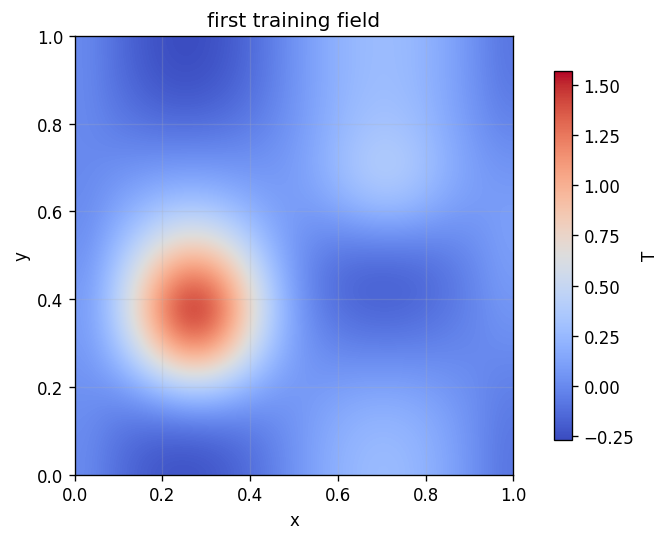

In [2]:

n_modes = 4
n_sensors = 5
field_limits = (float(T.min()), float(T.max()))
fig, ax = plt.subplots(figsize=(5.8, 4.4), constrained_layout=True)
im = spatial_frame(ax, T[0], "first training field", field_limits)
fig.colorbar(im, ax=ax, shrink=0.84, label="T")


## RAVEN Constraint Gallery
Each row below shows the constrained region on the left and the RAVEN XML fragment that creates it on the right. The executable comparison later in the notebook runs the 2D examples against pySensors using the current temperature field; the 3D cylinder row is included as a supported RAVEN pattern for data sets with `x`, `y`, and `z` coordinates.


## Define GQR cases

In [3]:

hotspot_index = int(np.argmax(T[0]))
constraint_cases = [
    {
        "name": "circle_max_n",
        "label": "Circle max_n exclusion",
        "strategy": "max_n",
        "shape": "Circle",
        "params": {"centerX": 0.50, "centerY": 0.50, "radius": 0.22, "loc": "in", "nConstSensors": 0},
    },
    {
        "name": "ellipse_exact_n",
        "label": "Ellipse exact_n",
        "strategy": "exact_n",
        "shape": "Ellipse",
        "params": {"centerX": 0.68, "centerY": 0.63, "width": 0.36, "height": 0.22, "angle": 25.0, "loc": "in", "nConstSensors": 1},
    },
    {
        "name": "polygon_max_n",
        "label": "Polygon max_n exclusion",
        "strategy": "max_n",
        "shape": "Polygon",
        "params": {"vertices": [(0.18, 0.18), (0.46, 0.24), (0.36, 0.58), (0.12, 0.50)], "loc": "in", "nConstSensors": 0},
    },
    {
        "name": "line_exact_n",
        "label": "Line half-plane exact_n",
        "strategy": "exact_n",
        "shape": "Line",
        "params": {"x1": 0.18, "x2": 0.86, "y1": 0.78, "y2": 0.22, "nConstSensors": 1},
    },
    {
        "name": "parabola_max_n",
        "label": "Parabola max_n",
        "strategy": "max_n",
        "shape": "Parabola",
        "params": {"h": 0.50, "k": 0.18, "a": 2.8, "loc": "in", "nConstSensors": 1},
    },
    {
        "name": "user_defined_equation",
        "label": "UserDefined equation max_n",
        "strategy": "max_n",
        "shape": "UserDefined",
        "params": {"equation": "((x - 0.78)**2 + (y - 0.25)**2) > 0.035", "nConstSensors": 0},
    },
    {
        "name": "predetermined",
        "label": "Predetermined hotspot",
        "strategy": "predetermined",
        "indices": [hotspot_index],
        "params": {"nConstSensors": 1},
    },
    {
        "name": "distance",
        "label": "Minimum spacing",
        "strategy": "distance",
        "params": {"radius": 0.24},
    },
]
pd.DataFrame([{k: v for k, v in case.items() if k not in ["params"]} for case in constraint_cases])


,name,label,strategy,shape,indices
0,circle_max_n,Circle max_n exclusion,max_n,Circle,NaN
1,ellipse_exact_n,Ellipse exact_n,exact_n,Ellipse,NaN
2,polygon_max_n,Polygon max_n exclusion,max_n,Polygon,NaN
3,line_exact_n,Line half-plane exact_n,exact_n,Line,NaN
4,parabola_max_n,Parabola max_n,max_n,Parabola,NaN
5,user_defined_equation,UserDefined equation max_n,max_n,UserDefined,NaN
6,predetermined,Predetermined hotspot,predetermined,NaN,[76]
7,distance,Minimum spacing,distance,NaN,NaN


## Constraint Visuals and XML
The XML snippets here are the actual `<constraint>` blocks inserted into the SparseSensing PostProcessor. Strategies control how many selected sensors may lie in the constrained set: `max_n`, `exact_n`, `predetermined`, and `distance`.


Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>Circle</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <centerX>0.5</centerX> <centerY>0.5</centerY> <radius>0.22</radius> <loc>in</loc> <nConstSensors>0</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

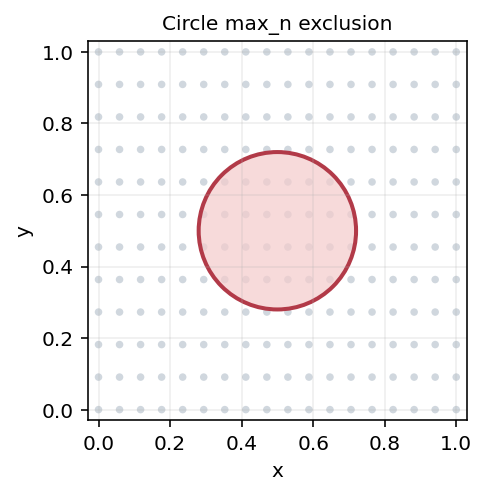

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""exact_n""> <shape>Ellipse</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <centerX>0.68</centerX> <centerY>0.63</centerY> <height>0.22</height> <width>0.36</width> <angle>25.0</angle> <loc>in</loc> <nConstSensors>1</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

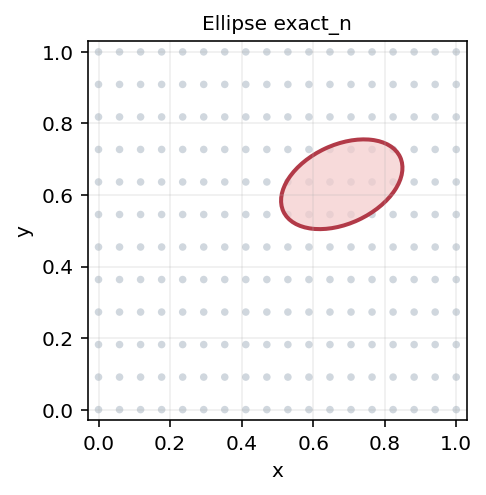

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>Polygon</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <loc>in</loc> <nConstSensors>0</nConstSensors> <vertex>0.18,0.18</vertex> <vertex>0.46,0.24</vertex> <vertex>0.36,0.58</vertex> <vertex>0.12,0.5</vertex> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

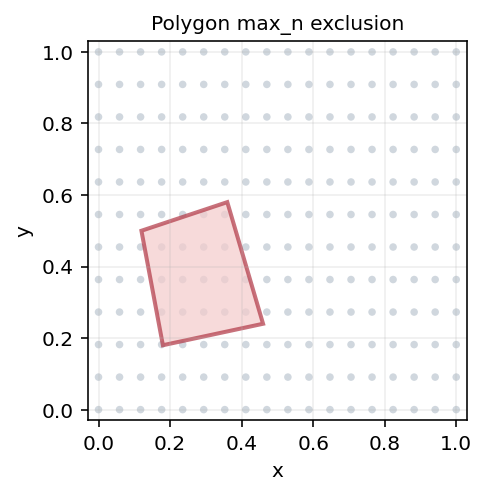

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""exact_n""> <shape>Line</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <x1>0.18</x1> <x2>0.86</x2> <y1>0.78</y1> <y2>0.22</y2> <nConstSensors>1</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

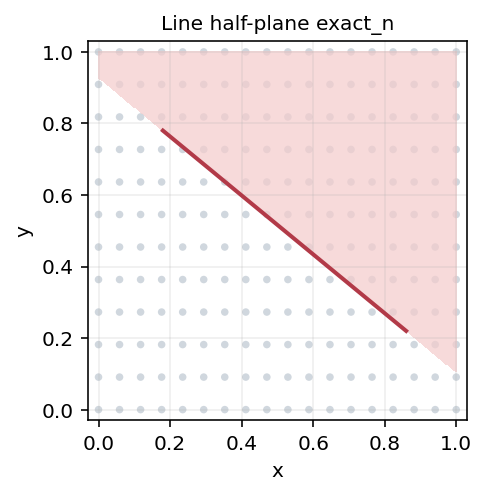

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>Parabola</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <h>0.5</h> <k>0.18</k> <a>2.8</a> <loc>in</loc> <nConstSensors>1</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

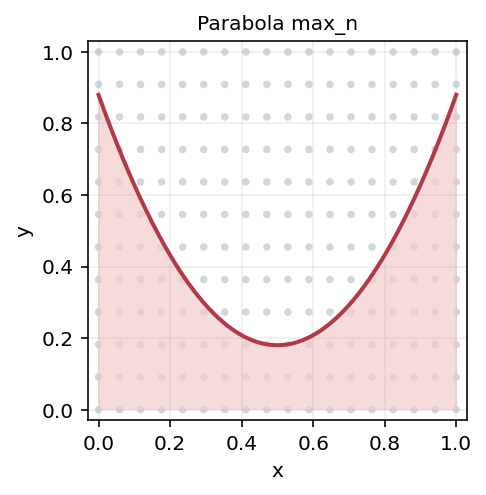

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>UserDefined</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <nConstSensors>0</nConstSensors> <equation>((x - 0.78)**2 + (y - 0.25)**2) &gt; 0.035</equation> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

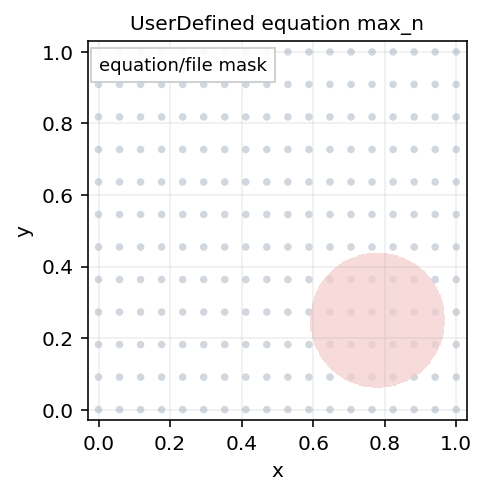

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""predetermined""> <indices>76</indices> <nConstSensors>1</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

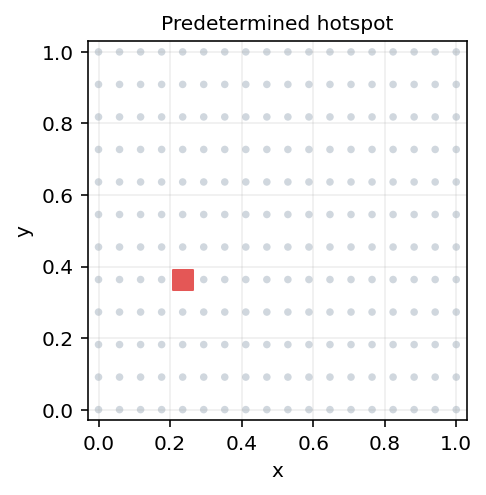

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""distance""> <xAxis>x</xAxis> <yAxis>y</yAxis> <radius>0.24</radius> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

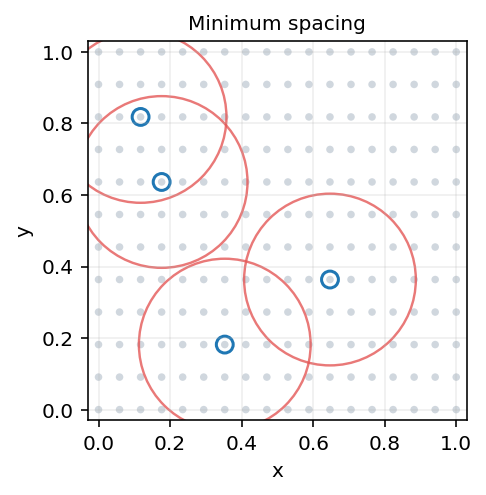

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>UserDefined</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <nConstSensors>0</nConstSensors> <file>my_constraint.py</file> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

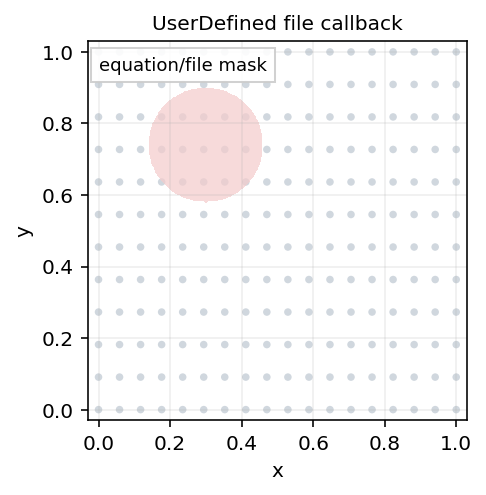

Constraint footprint,RAVEN XML
,"<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""reconstruction""> <features>x, y, T</features> <target>T</target> <basis>SVD</basis> <nModes>4</nModes> <nSensors>5</nSensors> <optimizer>GQR</optimizer> <constraint strategy=""max_n""> <shape>Cylinder</shape> <xAxis>x</xAxis> <yAxis>y</yAxis> <zAxis>z</zAxis> <centerX>0.5</centerX> <centerY>0.5</centerY> <centerZ>0.5</centerZ> <radius>0.24</radius> <height>0.6</height> <loc>in</loc> <nConstSensors>0</nConstSensors> </constraint> <seed>42</seed> </Goal> </PostProcessor>"

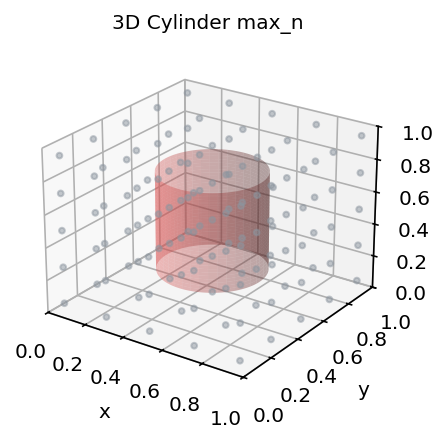

In [4]:

import base64
import io


def constraint_xml(case, indent="    "):
    params = case.get("params", {})
    pad = indent
    strategy = case["strategy"]
    if strategy == "distance":
        return "\n".join([
            f'{pad}<constraint strategy="distance">',
            f'{pad}  <xAxis>x</xAxis>',
            f'{pad}  <yAxis>y</yAxis>',
            f'{pad}  <radius>{params["radius"]}</radius>',
            f'{pad}</constraint>',
        ])
    if "indices" in case:
        indices = ",".join(str(index) for index in case["indices"])
        return "\n".join([
            f'{pad}<constraint strategy="{strategy}">',
            f'{pad}  <indices>{indices}</indices>',
            f'{pad}  <nConstSensors>{params["nConstSensors"]}</nConstSensors>',
            f'{pad}</constraint>',
        ])

    lines = [
        f'{pad}<constraint strategy="{strategy}">',
        f'{pad}  <shape>{case["shape"]}</shape>',
        f'{pad}  <xAxis>{case.get("xAxis", "x")}</xAxis>',
        f'{pad}  <yAxis>{case.get("yAxis", "y")}</yAxis>',
    ]
    if "zAxis" in case:
        lines.append(f'{pad}  <zAxis>{case["zAxis"]}</zAxis>')
    for key in ["centerX", "centerY", "centerZ", "radius", "height", "width", "angle", "x1", "x2", "y1", "y2", "h", "k", "a", "loc", "nConstSensors"]:
        if key in params:
            lines.append(f'{pad}  <{key}>{params[key]}</{key}>')
    for vertex in params.get("vertices", []):
        lines.append(f'{pad}  <vertex>{vertex[0]},{vertex[1]}</vertex>')
    if "equation" in params:
        lines.append(f'{pad}  <equation>{html.escape(params["equation"])}</equation>')
    if "file" in params:
        lines.append(f'{pad}  <file>{params["file"]}</file>')
    lines.append(f'{pad}</constraint>')
    return "\n".join(lines)


def raven_postprocessor_xml(case):
    return f"""
<PostProcessor name="mySPSL" subType="SparseSensing">
  <Goal subType="reconstruction">
    <features>x, y, T</features>
    <target>T</target>
    <basis>SVD</basis>
    <nModes>{n_modes}</nModes>
    <nSensors>{n_sensors}</nSensors>
    <optimizer>GQR</optimizer>
{constraint_xml(case, indent="    ")}
    <seed>{seed}</seed>
  </Goal>
</PostProcessor>
""".strip()


def draw_2d_constraint_preview(ax, case):
    params = case.get("params", {})
    ax.scatter(X, Y, s=14, c="#d0d7de", edgecolors="none")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(case["label"], fontsize=10)
    xx = np.linspace(0, 1, 300)
    yy = np.linspace(0, 1, 300)
    GX, GY = np.meshgrid(xx, yy)
    shape = case.get("shape")

    if case["strategy"] == "distance":
        chosen = np.array([42, 83, 129, 164])
        ax.scatter(X[chosen], Y[chosen], s=70, facecolors="none", edgecolors="#1f77b4", linewidths=1.5)
        for index in chosen:
            ax.add_patch(patches.Circle((X[index], Y[index]), params["radius"], fill=False, edgecolor="#e45756", linewidth=1.2, alpha=0.8))
        return
    if "indices" in case:
        idx = np.asarray(case["indices"], dtype=int)
        ax.scatter(X[idx], Y[idx], marker="s", s=95, c="#e45756", label="prescribed")
        return
    if shape == "Circle":
        mask = (GX - params["centerX"]) ** 2 + (GY - params["centerY"]) ** 2 <= params["radius"] ** 2
        if params.get("loc", "in") == "out":
            mask = ~mask
        ax.contourf(GX, GY, mask.astype(float), levels=[0.5, 1.5], colors=["#f4cccc"], alpha=0.72)
        ax.add_patch(patches.Circle((params["centerX"], params["centerY"]), params["radius"], fill=False, edgecolor="#b23a48", linewidth=2.0))
    elif shape == "Ellipse":
        theta = np.deg2rad(params.get("angle", 0.0))
        X0 = GX - params["centerX"]
        Y0 = GY - params["centerY"]
        xr = X0 * np.cos(theta) + Y0 * np.sin(theta)
        yr = -X0 * np.sin(theta) + Y0 * np.cos(theta)
        mask = (xr / (params["width"] / 2.0)) ** 2 + (yr / (params["height"] / 2.0)) ** 2 <= 1.0
        if params.get("loc", "in") == "out":
            mask = ~mask
        ax.contourf(GX, GY, mask.astype(float), levels=[0.5, 1.5], colors=["#f4cccc"], alpha=0.72)
        ax.add_patch(patches.Ellipse((params["centerX"], params["centerY"]), params["width"], params["height"], angle=params.get("angle", 0.0), fill=False, edgecolor="#b23a48", linewidth=2.0))
    elif shape == "Polygon":
        ax.add_patch(patches.Polygon(params["vertices"], closed=True, facecolor="#f4cccc", edgecolor="#b23a48", linewidth=2.0, alpha=0.72))
    elif shape == "Line":
        mask = (GY - params["y1"]) * (params["x2"] - params["x1"]) - (params["y2"] - params["y1"]) * (GX - params["x1"]) >= 0
        ax.contourf(GX, GY, mask.astype(float), levels=[0.5, 1.5], colors=["#f4cccc"], alpha=0.72)
        ax.plot([params["x1"], params["x2"]], [params["y1"], params["y2"]], color="#b23a48", linewidth=2.0)
    elif shape == "Parabola":
        curve = params["a"] * (xx - params["h"]) ** 2 + params["k"]
        mask = params["a"] * (GX - params["h"]) ** 2 <= (GY - params["k"])
        if params.get("loc", "in") == "in":
            mask = ~mask
        ax.contourf(GX, GY, mask.astype(float), levels=[0.5, 1.5], colors=["#f4cccc"], alpha=0.72)
        ax.plot(xx, curve, color="#b23a48", linewidth=2.0)
    elif shape == "UserDefined":
        equation = params.get("equation", params.get("previewEquation", "((x - 0.78)**2 + (y - 0.25)**2) > 0.035"))
        mask = np.zeros_like(GX, dtype=bool)
        for row in range(GX.shape[0]):
            for col in range(GX.shape[1]):
                x = float(GX[row, col])
                y = float(GY[row, col])
                mask[row, col] = not bool(eval(equation, {"__builtins__": {}}, {"x": x, "y": y, "np": np}))
        ax.contourf(GX, GY, mask.astype(float), levels=[0.5, 1.5], colors=["#f4cccc"], alpha=0.72)
        ax.text(0.03, 0.96, "equation/file mask", transform=ax.transAxes, va="top", fontsize=9, bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9})


def draw_cylinder_preview(ax, case):
    params = case["params"]
    theta = np.linspace(0, 2 * np.pi, 80)
    z = np.linspace(params["centerZ"] - params["height"] / 2, params["centerZ"] + params["height"] / 2, 30)
    TH, ZZ = np.meshgrid(theta, z)
    CX = params["centerX"] + params["radius"] * np.cos(TH)
    CY = params["centerY"] + params["radius"] * np.sin(TH)
    ax.plot_surface(CX, CY, ZZ, color="#e45756", alpha=0.38, linewidth=0)
    pts = np.linspace(0.05, 0.95, 5)
    PX, PY, PZ = np.meshgrid(pts, pts, pts)
    ax.scatter(PX.ravel(), PY.ravel(), PZ.ravel(), s=8, c="#8c959f", alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(case["label"], fontsize=10)
    ax.view_init(elev=24, azim=-55)


def constraint_preview_png(case):
    if case.get("shape") == "Cylinder":
        fig = plt.figure(figsize=(4.2, 3.3))
        ax = fig.add_subplot(111, projection="3d")
        draw_cylinder_preview(ax, case)
    else:
        fig, ax = plt.subplots(figsize=(4.2, 3.3), constrained_layout=True)
        draw_2d_constraint_preview(ax, case)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=145, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buffer.getvalue()).decode("ascii")


def display_constraint_gallery(case):
    image_data = constraint_preview_png(case)
    xml = html.escape(raven_postprocessor_xml(case))
    return HTML(f"""
    <table style="width:100%; border-collapse:collapse; table-layout:fixed; margin:0.6rem 0 1.0rem 0;">
      <tr>
        <th style="width:42%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">Constraint footprint</th>
        <th style="width:58%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">RAVEN XML</th>
      </tr>
      <tr>
        <td style="vertical-align:top; border:1px solid #d0d7de; padding:8px; background:#ffffff;">
          <img alt="{html.escape(case['label'])}" src="data:image/png;base64,{image_data}" style="width:100%; height:auto;" />
        </td>
        <td style="vertical-align:top; border:1px solid #d0d7de; padding:0;">
          <pre style="white-space:pre-wrap; overflow-x:auto; margin:0; padding:12px; background:#ffffff;"><code>{xml}</code></pre>
        </td>
      </tr>
    </table>
    """)


constraint_gallery_cases = constraint_cases + [
    {
        "name": "user_defined_file",
        "label": "UserDefined file callback",
        "strategy": "max_n",
        "shape": "UserDefined",
        "params": {"file": "my_constraint.py", "previewEquation": "((x - 0.30)**2 + (y - 0.74)**2) > 0.025", "nConstSensors": 0},
    },
    {
        "name": "cylinder_3d",
        "label": "3D Cylinder max_n",
        "strategy": "max_n",
        "shape": "Cylinder",
        "zAxis": "z",
        "params": {"centerX": 0.50, "centerY": 0.50, "centerZ": 0.50, "radius": 0.24, "height": 0.60, "loc": "in", "nConstSensors": 0},
    },
]

for case in constraint_gallery_cases:
    display(display_constraint_gallery(case))


In [5]:

def reference_all_sensors():
    reference = ps.SSPOR(
        basis=ps.basis.SVD(n_basis_modes=n_modes, random_state=seed),
        n_sensors=n_sensors,
        optimizer=ps.optimizers.QR(),
    )
    reference.fit(T, seed=seed)
    return np.asarray(reference.get_all_sensors(), dtype=int)


def constrained_indices_from_shape(case, all_sensors):
    params = case["params"]
    common = {"data": info_df, "X_axis": "x", "Y_axis": "y", "Field": "T"}
    loc = params.get("loc", "in")
    shape = case["shape"]
    if shape == "Circle":
        constraint = ps.utils.Circle(params["centerX"], params["centerY"], params["radius"], loc=loc, **common)
    elif shape == "Ellipse":
        constraint = ps.utils.Ellipse(params["centerX"], params["centerY"], params["width"], params["height"], angle=params.get("angle", 0.0), loc=loc, **common)
    elif shape == "Polygon":
        constraint = ps.utils.Polygon(params["vertices"], loc=loc, **common)
    elif shape == "Line":
        constraint = ps.utils.Line(params["x1"], params["x2"], params["y1"], params["y2"], **common)
    elif shape == "Parabola":
        constraint = ps.utils.Parabola(params["h"], params["k"], params["a"], params["loc"], **common)
    elif shape == "UserDefined":
        constraint = ps.utils.UserDefinedConstraints(all_sensors, equation=params["equation"], **common)
        idx, _ = constraint.constraint()
        return np.asarray(idx, dtype=int)
    else:
        raise ValueError(shape)
    idx, _ = constraint.get_constraint_indices(all_sensors, info_df)
    return np.asarray(idx, dtype=int)


def fit_pysensors_gqr(case):
    all_sensors = reference_all_sensors()
    optimizer_kws = {"all_sensors": all_sensors, "n_sensors": n_sensors, "constraint_option": case["strategy"]}
    if case["strategy"] == "distance":
        optimizer_kws.update({"info": info_df, "r": case["params"]["radius"], "X_axis": "x", "Y_axis": "y"})
    elif "indices" in case:
        optimizer_kws.update({"idx_constrained": np.asarray(case["indices"], dtype=int), "n_const_sensors": case["params"]["nConstSensors"]})
    else:
        optimizer_kws.update({"idx_constrained": constrained_indices_from_shape(case, all_sensors), "n_const_sensors": case["params"]["nConstSensors"]})
    model = ps.SSPOR(
        basis=ps.basis.SVD(n_basis_modes=n_modes, random_state=seed),
        n_sensors=n_sensors,
        optimizer=ps.optimizers.GQR(),
    )
    model.fit(T, seed=seed, **optimizer_kws)
    return model, optimizer_kws


py_results = {}
for case in constraint_cases:
    fitted, kws = fit_pysensors_gqr(case)
    py_results[case["name"]] = {"model": fitted, "sensors": fitted.get_selected_sensors(), "optimizer_kws": kws}

pd.DataFrame({"case": case["name"], "selected_sensors": list(py_results[case["name"]]["sensors"])} for case in constraint_cases)


,case,selected_sensors
0,circle_max_n,"[76, 121, 17, 213, 28]"
1,ellipse_exact_n,"[76, 120, 17, 213, 28]"
2,polygon_max_n,"[120, 17, 213, 74, 28]"
3,line_exact_n,"[76, 120, 215, 213, 28]"
4,parabola_max_n,"[76, 120, 17, 15, 28]"
5,user_defined_equation,"[32, 83, 52, 30, 28]"
6,predetermined,"[77, 120, 17, 213, 28]"
7,distance,"[76, 120, 17, 213, 28]"


## Run fresh RAVEN GQR cases

In [6]:

raven_base_dir = repo_root / "tutorials" / "SparseSensing" / "_raven_runs" / "07_gqr_constraints"
raven_base_dir.mkdir(parents=True, exist_ok=True)
write_steady_external_model(raven_base_dir)
all_comparisons = []
raven_results = {}
raven_input_paths = {}
for case in constraint_cases:
    goal = f"""
<features>x, y, T</features>
<target>T</target>
<basis>SVD</basis>
<nModes>{n_modes}</nModes>
<nSensors>{n_sensors}</nSensors>
<optimizer>GQR</optimizer>
{constraint_xml(case, indent="")}
<seed>{seed}</seed>
"""
    raven_input = write_steady_xml(raven_base_dir, case["name"], goal, "sensor")
    raven_input_paths[case["name"]] = raven_input
    raven_frame = run_raven(raven_base_dir, raven_input)
    comparison, raven_indices = compare_sensor_tables(case["name"], py_results[case["name"]]["sensors"], raven_frame, T)
    all_comparisons.append(comparison)
    raven_results[case["name"]] = {"frame": raven_frame, "indices": raven_indices}

comparison_table = pd.concat(all_comparisons, ignore_index=True)
summary = comparison_table.groupby("case").agg(match=("match", "all"), order_match=("order_match", "all"), rows=("sensor_id", "count"))
print(summary)
display(style_sensor_comparison(comparison_table, "RAVEN vs pySensors GQR constrained sensors"))


$ raven_framework circle_max_n.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ###   ### 

CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ###   ###  ###   ###  ######    ### ######
  

case,match,order_match,sensor_id,pySensors order,RAVEN order,pySensors value,RAVEN value,pySensors x,RAVEN x,pySensors y,RAVEN y,nearest_grid_distance
circle_max_n,yes,yes,76,1,1,1.515462,1.515462,0.235294,0.235294,0.363636,0.363636,6.21e-17
circle_max_n,yes,yes,121,2,2,0.010698,0.010698,0.764706,0.764706,0.545455,0.545455,0.00e+00
circle_max_n,yes,yes,17,3,3,-0.082290,-0.082290,1.000000,1.000000,0.000000,0.000000,0.00e+00
circle_max_n,yes,yes,213,4,4,0.122023,0.122023,0.882353,0.882353,1.000000,1.000000,0.00e+00
circle_max_n,yes,yes,28,5,5,0.153510,0.153510,0.588235,0.588235,0.090909,0.090909,1.39e-17
ellipse_exact_n,yes,yes,76,1,1,1.515462,1.515462,0.235294,0.235294,0.363636,0.363636,6.21e-17
ellipse_exact_n,yes,yes,120,2,2,0.011646,0.011646,0.705882,0.705882,0.545455,0.545455,0.00e+00
ellipse_exact_n,yes,yes,17,3,3,-0.082290,-0.082290,1.000000,1.000000,0.000000,0.000000,0.00e+00
ellipse_exact_n,yes,yes,213,4,4,0.122023,0.122023,0.882353,0.882353,1.000000,1.000000,0.00e+00
ellipse_exact_n,yes,yes,28,5,5,0.153510,0.153510,0.588235,0.588235,0.090909,0.090909,1.39e-17


## Inspect a Generated RAVEN Input
The RAVEN cells above write a complete XML input for every constraint case, then invoke `raven_framework <case>.xml` from inside the notebook. This cell opens one generated input so the PostProcessor block can be seen in its full Simulation context.


In [7]:

example_case_name = constraint_cases[0]["name"]
example_input = raven_input_paths[example_case_name]
print(f"Generated RAVEN input: {example_input}")
display(HTML(f"""
<details open>
  <summary>Full generated RAVEN input: {html.escape(example_input.name)}</summary>
  <pre style="white-space:pre-wrap; overflow-x:auto; margin:0.5rem 0 0 0; padding:12px; border:1px solid #d0d7de; background:#ffffff;"><code>{html.escape(example_input.read_text())}</code></pre>
</details>
"""))


Generated RAVEN input: /Users/abdomg/projects/raven-pysensors-alignment/tutorials/SparseSensing/_raven_runs/07_gqr_constraints/circle_max_n.xml


## Reconstruction Diagnostics
For each constrained GQR case, the selected sensors are used for unregularized reconstruction. The plot below shows a representative constrained case with the same true/reconstruction/relative-error layout used in the earlier notebooks.


case,relative_l2_error,rmse
circle_max_n,1.146365e-03,4.397866e-04
ellipse_exact_n,1.171598e-03,4.494669e-04
polygon_max_n,1.716056e-03,6.583405e-04
line_exact_n,1.172158e-03,4.496817e-04
parabola_max_n,1.171049e-03,4.492560e-04
user_defined_equation,4.988671e-03,1.913832e-03
predetermined,1.203612e-03,4.617485e-04
distance,1.171598e-03,4.494669e-04


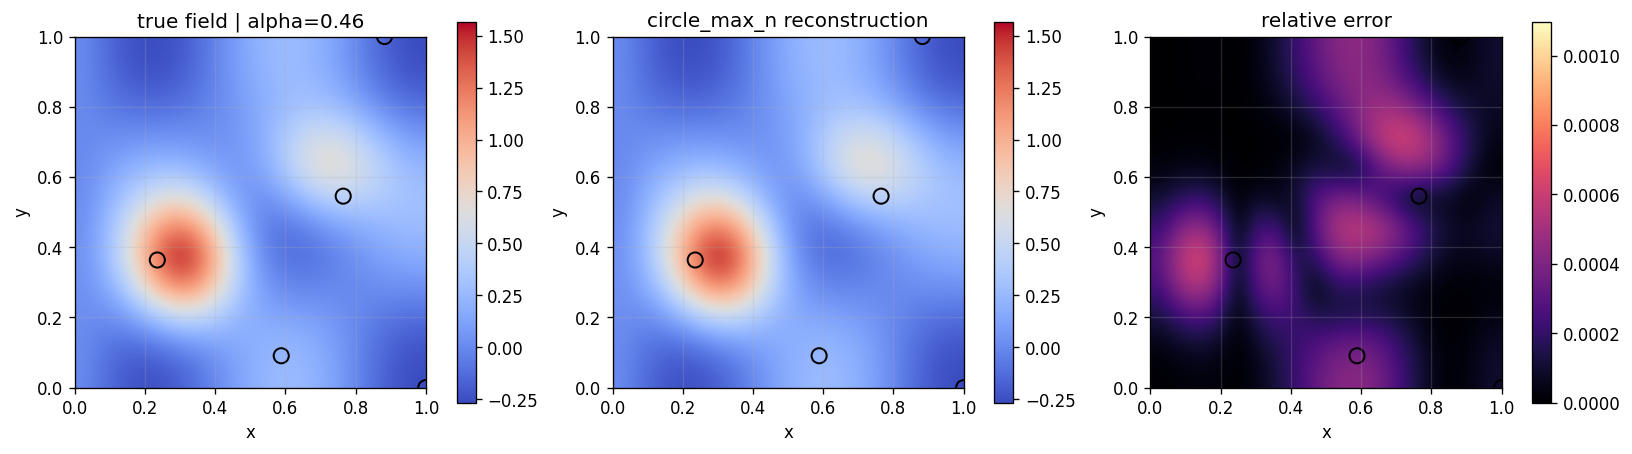

In [8]:

reconstruction_rows = []
for case in constraint_cases:
    case_name = case["name"]
    case_model = py_results[case_name]["model"]
    case_sensors = np.asarray(py_results[case_name]["sensors"], dtype=int)
    case_reconstruction = case_model.predict(T[:, case_sensors], method="unregularized")
    reconstruction_rows.append({
        "case": case_name,
        "relative_l2_error": np.linalg.norm(case_reconstruction - T) / max(np.linalg.norm(T), 1e-12),
        "rmse": float(np.sqrt(np.mean((case_reconstruction - T) ** 2))),
    })
reconstruction_table = pd.DataFrame(reconstruction_rows)
display(reconstruction_table.style.format({"relative_l2_error": "{:.6e}", "rmse": "{:.6e}"}).hide(axis="index"))

diagnostic_case = constraint_cases[0]["name"]
diagnostic_model = py_results[diagnostic_case]["model"]
diagnostic_sensors = np.asarray(py_results[diagnostic_case]["sensors"], dtype=int)
diagnostic_reconstruction = diagnostic_model.predict(T[:, diagnostic_sensors], method="unregularized")
diagnostic_relative_error = np.abs(diagnostic_reconstruction - T) / max(float(np.max(np.abs(T))), 1e-12)
sample_index = min(2, len(alphas) - 1)
field_limits = (float(np.min(T)), float(np.max(T)))
error_limits = (0.0, max(float(np.max(diagnostic_relative_error)), 1e-12))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)
panels = [
    (T[sample_index], f"true field | alpha={alphas[sample_index]:.2f}", "coolwarm", field_limits),
    (diagnostic_reconstruction[sample_index], f"{diagnostic_case} reconstruction", "coolwarm", field_limits),
    (diagnostic_relative_error[sample_index], "relative error", "magma", error_limits),
]
for ax, (values, title, cmap, limits) in zip(axes, panels):
    im = spatial_frame(ax, values, title, limits=limits, cmap=cmap, sensors=diagnostic_sensors)
    fig.colorbar(im, ax=ax, shrink=0.82)


## pySensors and RAVEN Constrained Selections
The final visual check uses the same field, the same constraint footprint, and the same selected-sensor overlay for both implementations. The left column is pySensors; the right column is the fresh RAVEN run.


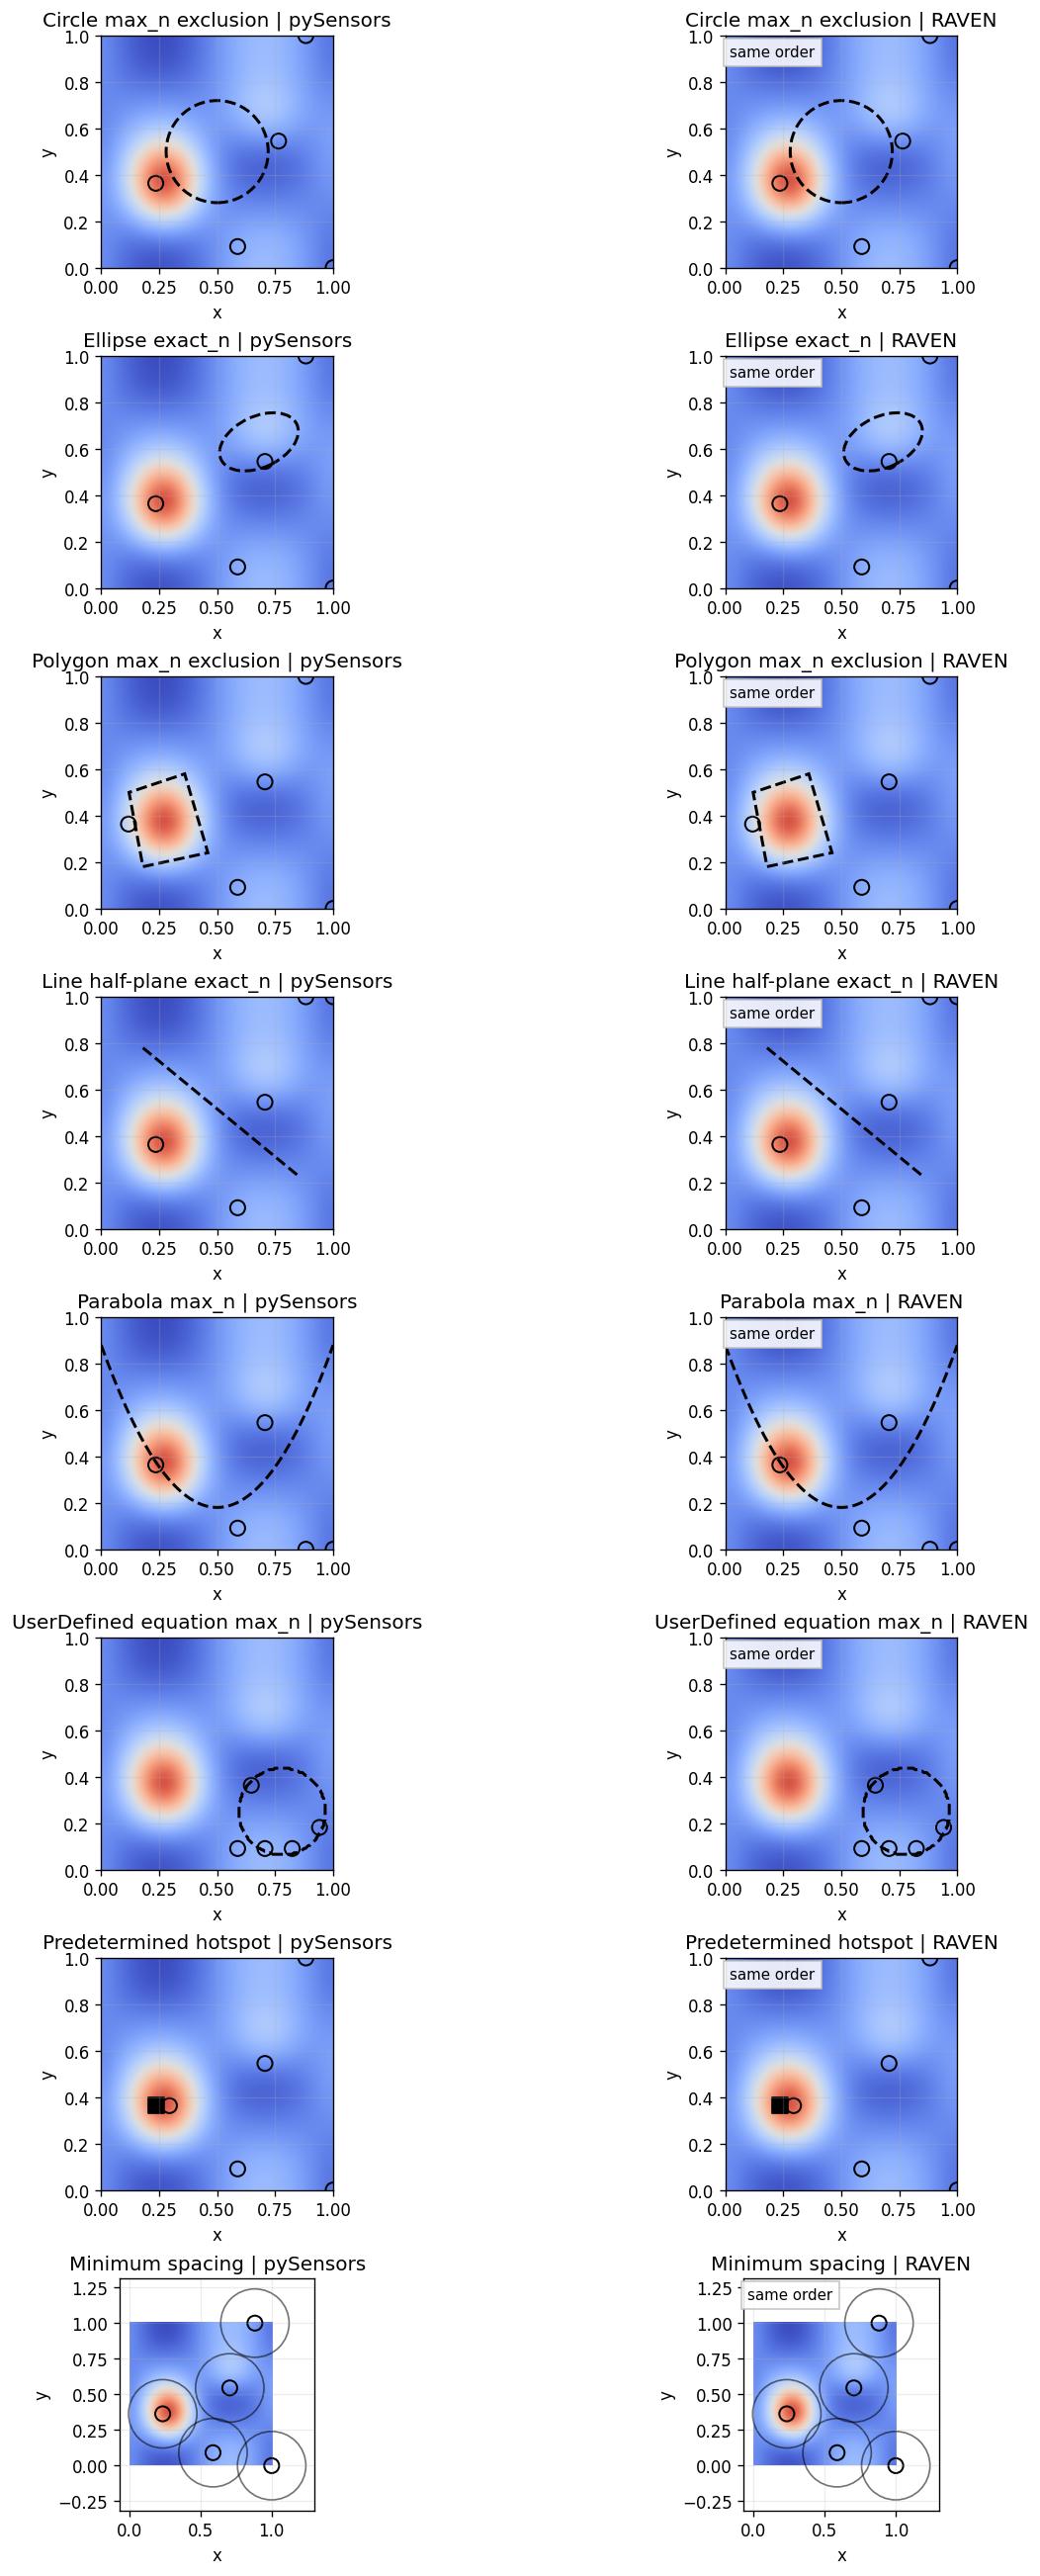

In [9]:

def draw_constraint(ax, case):
    params = case.get("params", {})
    shape = case.get("shape")
    if shape == "Circle":
        ax.add_patch(patches.Circle((params["centerX"], params["centerY"]), params["radius"], fill=False, edgecolor="black", linewidth=1.8, linestyle="--"))
    elif shape == "Ellipse":
        ax.add_patch(patches.Ellipse((params["centerX"], params["centerY"]), params["width"], params["height"], angle=params.get("angle", 0.0), fill=False, edgecolor="black", linewidth=1.8, linestyle="--"))
    elif shape == "Polygon":
        ax.add_patch(patches.Polygon(params["vertices"], fill=False, edgecolor="black", linewidth=1.8, linestyle="--"))
    elif shape == "Line":
        ax.plot([params["x1"], params["x2"]], [params["y1"], params["y2"]], color="black", linewidth=1.8, linestyle="--")
    elif shape == "Parabola":
        xx = np.linspace(0.0, 1.0, 300)
        yy = params["a"] * (xx - params["h"]) ** 2 + params["k"]
        ax.plot(xx, yy, color="black", linewidth=1.8, linestyle="--")
    elif shape == "UserDefined":
        equation = params["equation"]
        xx = np.linspace(0.0, 1.0, 160)
        yy = np.linspace(0.0, 1.0, 160)
        GX, GY = np.meshgrid(xx, yy)
        mask = np.zeros_like(GX, dtype=bool)
        for row in range(GX.shape[0]):
            for col in range(GX.shape[1]):
                x = float(GX[row, col])
                y = float(GY[row, col])
                mask[row, col] = not bool(eval(equation, {"__builtins__": {}}, {"x": x, "y": y, "np": np}))
        ax.contour(GX, GY, mask.astype(float), levels=[0.5], colors="black", linewidths=1.8, linestyles="--")
    elif "indices" in case:
        idx = np.asarray(case["indices"], dtype=int)
        ax.scatter(X[idx], Y[idx], marker="s", s=90, c="black", label="prescribed")
    elif case["strategy"] == "distance":
        for index in raven_results[case["name"]]["indices"]:
            ax.add_patch(patches.Circle((X[index], Y[index]), params["radius"], fill=False, edgecolor="black", linewidth=1.0, alpha=0.55))


fig, axes = plt.subplots(len(constraint_cases), 2, figsize=(10.5, 2.7 * len(constraint_cases)), constrained_layout=True)
for row, case in enumerate(constraint_cases):
    py_sensors = np.asarray(py_results[case["name"]]["sensors"], dtype=int)
    raven_sensors = np.asarray(raven_results[case["name"]]["indices"], dtype=int)
    for col, (source_name, sensors) in enumerate([("pySensors", py_sensors), ("RAVEN", raven_sensors)]):
        ax = axes[row, col]
        title = f"{case['label']} | {source_name}"
        spatial_frame(ax, T[0], title, field_limits, sensors=sensors)
        draw_constraint(ax, case)
        if col == 1:
            match_text = "same order" if np.array_equal(py_sensors, raven_sensors) else "check order"
            ax.text(0.02, 0.96, match_text, transform=ax.transAxes, va="top", ha="left", fontsize=9, bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.88})
